In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_dilated_convolutions import CNNModel
from networks.cnn_network import build_dataloaders
from networks.cnn_dilated_convolutions import CNNNetwork


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

train_rows = df[df['set'] == 'train']
val_rows = df[df['set'] == 'val']
test_rows = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
#CNN.reset_weights()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
#CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)


Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553


In [2]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/convolution_dilated_version_fold1.pth
Epoch   0 | train: 0.6732 | val: 0.6243 | acc: 85.51% | AUC: 0.750  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_fold1.pth
Epoch   1 | train: 0.5238 | val: 0.4494 | acc: 90.71% | AUC: 0.873  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_fold1.pth
Epoch   2 | train: 0.3553 | val: 0.3053 | acc: 92.57% | AUC: 0.943  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_fold1.pth
Epoch   3 | train: 0.2431 | val: 0.2590 | acc: 95.87% | AUC: 0.965  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_fold1.pth
Epoch   4 | train: 0.2042 | val: 0.2563 | acc: 96.42% | AUC: 0.980  | LR: 0.001
  -> ny bästa modell sparad till ../mo

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.072763,0.118319,96.330701,0.992342,0.966561,0.940520,1821,63,16,253
1,2,0.036668,0.097917,97.353760,0.994819,0.979310,0.933086,1846,39,18,251
2,3,0.066368,0.099239,97.724106,0.991934,0.982484,0.940520,1851,33,16,253
3,4,0.120543,0.152079,92.568509,0.990436,0.919321,0.970260,1732,152,8,261
4,5,0.063748,0.114951,97.398978,0.990979,0.978238,0.944238,1843,41,15,254
5,6,0.080629,0.098493,97.211896,0.990403,0.976633,0.940520,1839,44,16,253
6,7,0.054345,0.166928,97.724106,0.988404,0.985138,0.921933,1856,28,21,248
7,8,0.047113,0.162072,98.049234,0.994388,0.988854,0.921933,1863,21,21,248
8,9,0.059047,0.122201,97.584765,0.992077,0.984068,0.918519,1853,30,22,248
9,10,0.063722,0.103764,97.724106,0.993924,0.984068,0.929630,1853,30,19,251


              precision    recall  f1-score   support

     Negativ       1.00      0.98      0.99      3151
     Positiv       0.74      0.96      0.83       139

    accuracy                           0.98      3290
   macro avg       0.87      0.97      0.91      3290
weighted avg       0.99      0.98      0.98      3290

[[3103   48]
 [   5  134]]


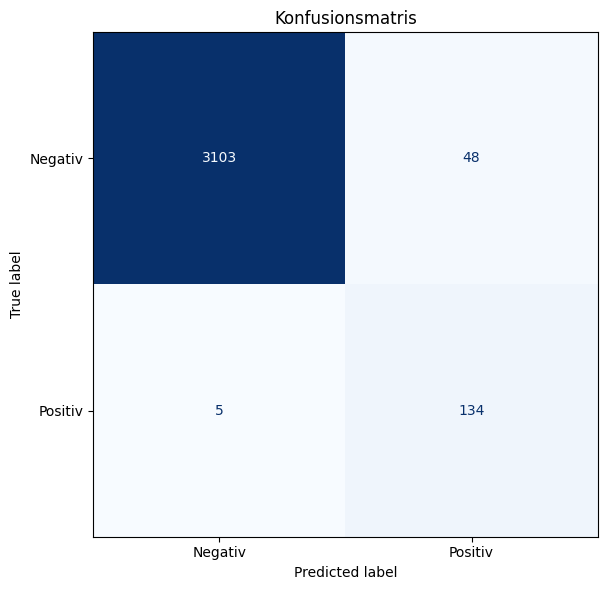

AUC: 0.9966962640614262
Accuracy:  98.39%
FN-rate:   3.60%  (farliga missade fall)
FP-rate:   1.52%  (onödiga larm)
Sensitivitet:   96.40%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.48%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9967


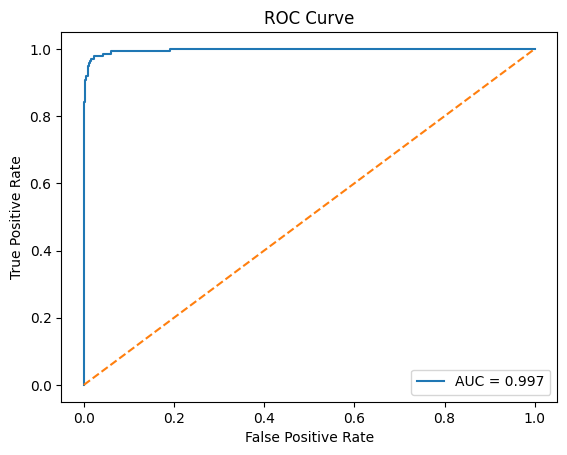

In [4]:
val_rows = val_rows[val_rows['label'].isin([0,1])]
result = CNN.predict(val_rows,threshold=0.2)
_ = evaluate(result)

In [4]:
import pandas as pd
df = pd.read_csv('../models/kfold_metrics.csv')
df

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.129538,0.257950,95.076637,0.968738,0.963887,0.859259,1815,68,38,232
1,2,0.154077,0.200881,95.636026,0.973038,0.971338,0.851852,1830,54,40,230
2,3,0.138266,0.218713,95.403900,0.965008,0.970292,0.840149,1829,56,43,226
3,4,0.143482,0.236672,95.726893,0.968984,0.972399,0.851301,1832,52,40,229
4,5,0.198901,0.249073,93.543892,0.959826,0.949575,0.836431,1789,95,44,225
5,6,0.135832,0.187881,95.726893,0.967791,0.968684,0.877323,1825,59,33,236
6,7,0.161182,0.210965,95.450325,0.961100,0.971353,0.836431,1831,54,44,225
7,8,0.157283,0.271179,95.353160,0.963015,0.975571,0.799257,1837,46,54,215
8,9,0.196945,0.290779,95.403900,0.956873,0.970292,0.840149,1829,56,43,226
9,10,0.131366,0.179935,96.144914,0.972527,0.974522,0.869888,1836,48,35,234
